## Microsoft Malware Prediction
## Group 40
## Chamodi Jayakody -EG/2021/4569
## Kavishka Kalhara -EG/2021/4593

## Introduction

### Background
Malware prediction is a critical task in cybersecurity, aimed at identifying and preventing potential malicious software threats. This project focuses on implementing machine learning techniques to predict malware characteristics using the Microsoft Malware Prediction dataset from Kaggle.

### Project Objectives
1. Implement and compare Random Forest and Support Vector Machine (SVM) models
2. Perform comprehensive data preprocessing
3. Conduct feature selection and engineering
4. Evaluate model performance using multiplnd limitations

## Literature Survey

### Previous Resear
* Recent studies in malware detection have explored various machine learning approaches:
- Discussing deep learning techniques in malware classification
- Comparing ensemble methods for cybersecurity threat detection
- Analyzing feature engineering strategies for improved malware predictioniction

### Theoretical Framework
Machine learning models have shown promising results in:
- Identifying complex patterns in malware signatures
- Reducing false positive rates
- Providing scalable threat detectiotion methodologies

## Dataset Description

### Data Source
- **Dataset:** Microsoft Malware Prediction Data
- **Source:** Kaggle
- **Total Samples:** 8921483 into 50000
- **Features:** 83

### Data Characteristics
- Binary classification problem (Malware detection)
- Target Variable: `HasDetections`
- Includes various system and software-related features

### Preprocessing Challenges
- Handling missing values
- Optimising time 

In [1]:
## Import Required Libraries

# Data Manipulation Libraries
import pandas as pd #For data manipulation and analysis
import numpy as np #For numerical computing and array operations

# Visualization Libraries
import matplotlib.pyplot as plt #For creating static, animated, and interactive visualizations
import seaborn as sns #For statistical data visualization based on matplotlib

# Machine Learning Libraries (Scikit-learn)
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectFromModel
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Machine Learning Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score, classification_report, 
    confusion_matrix, precision_score, 
    recall_score, f1_score,roc_curve, auc, 
    precision_recall_curve
)

# *Step 1. Data Loading*

#### This code uses pandas' read_csv() function with the chunksize parameter to read large CSV files in manageable chunks.

In [2]:
# Read the dataset in chunks
chunks = []
for chunk in pd.read_csv('/kaggle/input/microsoft-malware-prediction/train.csv', chunksize=100000, low_memory=False): #Reads the file in chunks of 100,000 rows
    chunks.append(chunk)

#### combines all the chunks into a single DataFrame

In [3]:
# Concatenate chunks
full_data = pd.concat(chunks, ignore_index=True)

In [4]:
# Stratified sampling
_, sampled_data = train_test_split(
    full_data, 
    train_size=50000, 
    stratify=full_data['HasDetections'], 
    random_state=42
) 

#### selects 50,000 random rows from the full dataset

In [5]:
# Random sampling
data = full_data.sample(n=50000, random_state=42)

# *Step 2. Exploratory Data Analysis*

### Basic Dataset Information
- **Total Samples:** 50,000
- **Number of Columns:** 83
- **Target Variable:** HasDetections

In [6]:
# Check dataset basic information
print("Original Dataset Shape:", full_data.shape)
print("Sampled Dataset Shape:", data.shape)
print("\nColumns:", list(data.columns))

Original Dataset Shape: (8921483, 83)
Sampled Dataset Shape: (50000, 83)

Columns: ['MachineIdentifier', 'ProductName', 'EngineVersion', 'AppVersion', 'AvSigVersion', 'IsBeta', 'RtpStateBitfield', 'IsSxsPassiveMode', 'DefaultBrowsersIdentifier', 'AVProductStatesIdentifier', 'AVProductsInstalled', 'AVProductsEnabled', 'HasTpm', 'CountryIdentifier', 'CityIdentifier', 'OrganizationIdentifier', 'GeoNameIdentifier', 'LocaleEnglishNameIdentifier', 'Platform', 'Processor', 'OsVer', 'OsBuild', 'OsSuite', 'OsPlatformSubRelease', 'OsBuildLab', 'SkuEdition', 'IsProtected', 'AutoSampleOptIn', 'PuaMode', 'SMode', 'IeVerIdentifier', 'SmartScreen', 'Firewall', 'UacLuaenable', 'Census_MDC2FormFactor', 'Census_DeviceFamily', 'Census_OEMNameIdentifier', 'Census_OEMModelIdentifier', 'Census_ProcessorCoreCount', 'Census_ProcessorManufacturerIdentifier', 'Census_ProcessorModelIdentifier', 'Census_ProcessorClass', 'Census_PrimaryDiskTotalCapacity', 'Census_PrimaryDiskTypeName', 'Census_SystemVolumeTotalCapa

In [7]:
# Target Variable Distribution
print("\nTarget Variable Distribution:")
print(data['HasDetections'].value_counts(normalize=True))


Target Variable Distribution:
HasDetections
1    0.5004
0    0.4996
Name: proportion, dtype: float64


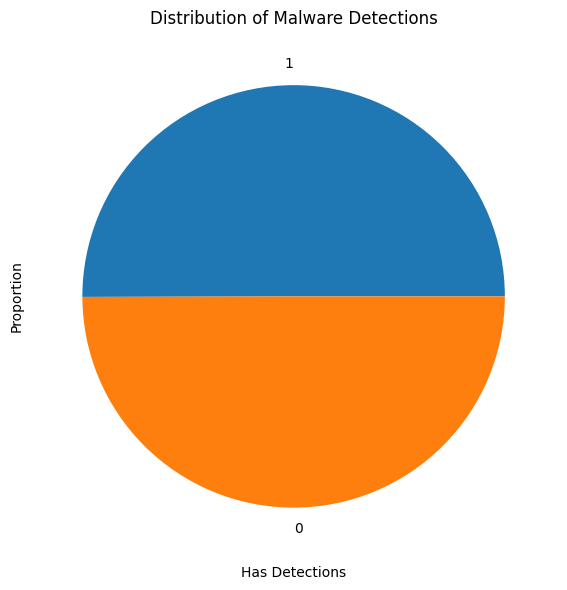

In [8]:
# Target variable distribution
plt.figure(figsize=(8, 6))
data['HasDetections'].value_counts(normalize=True).plot(kind='pie')

plt.title('Distribution of Malware Detections')
plt.xlabel('Has Detections')
plt.ylabel('Proportion')
plt.tight_layout()
plt.show()

In [9]:
# Duplicate Records
print("\nDuplicate Records:")
print(data.duplicated().sum())


Duplicate Records:
0


In [10]:
# Missing values analysis
missing_percentages = (data.isnull().mean() * 100).sort_values(ascending=False)
print("\nMissing Values Percentage:")
print(missing_percentages[missing_percentages > 0])


Missing Values Percentage:
PuaMode                                              99.972
Census_ProcessorClass                                99.594
DefaultBrowsersIdentifier                            95.256
Census_IsFlightingInternal                           83.026
Census_InternalBatteryType                           71.194
Census_ThresholdOptIn                                63.712
Census_IsWIMBootEnabled                              63.628
SmartScreen                                          35.718
OrganizationIdentifier                               30.654
SMode                                                 5.764
CityIdentifier                                        3.600
Wdft_IsGamer                                          3.392
Wdft_RegionIdentifier                                 3.392
Census_InternalBatteryNumberOfCharges                 3.000
Census_FirmwareManufacturerIdentifier                 2.044
Census_FirmwareVersionIdentifier                      1.810
Census_IsFli

### Correlation Matrix Analysis
* Close to 1: Strong positive correlation
* Close to -1: Strong negative correlation
* Close to 0: Weak or no correlation

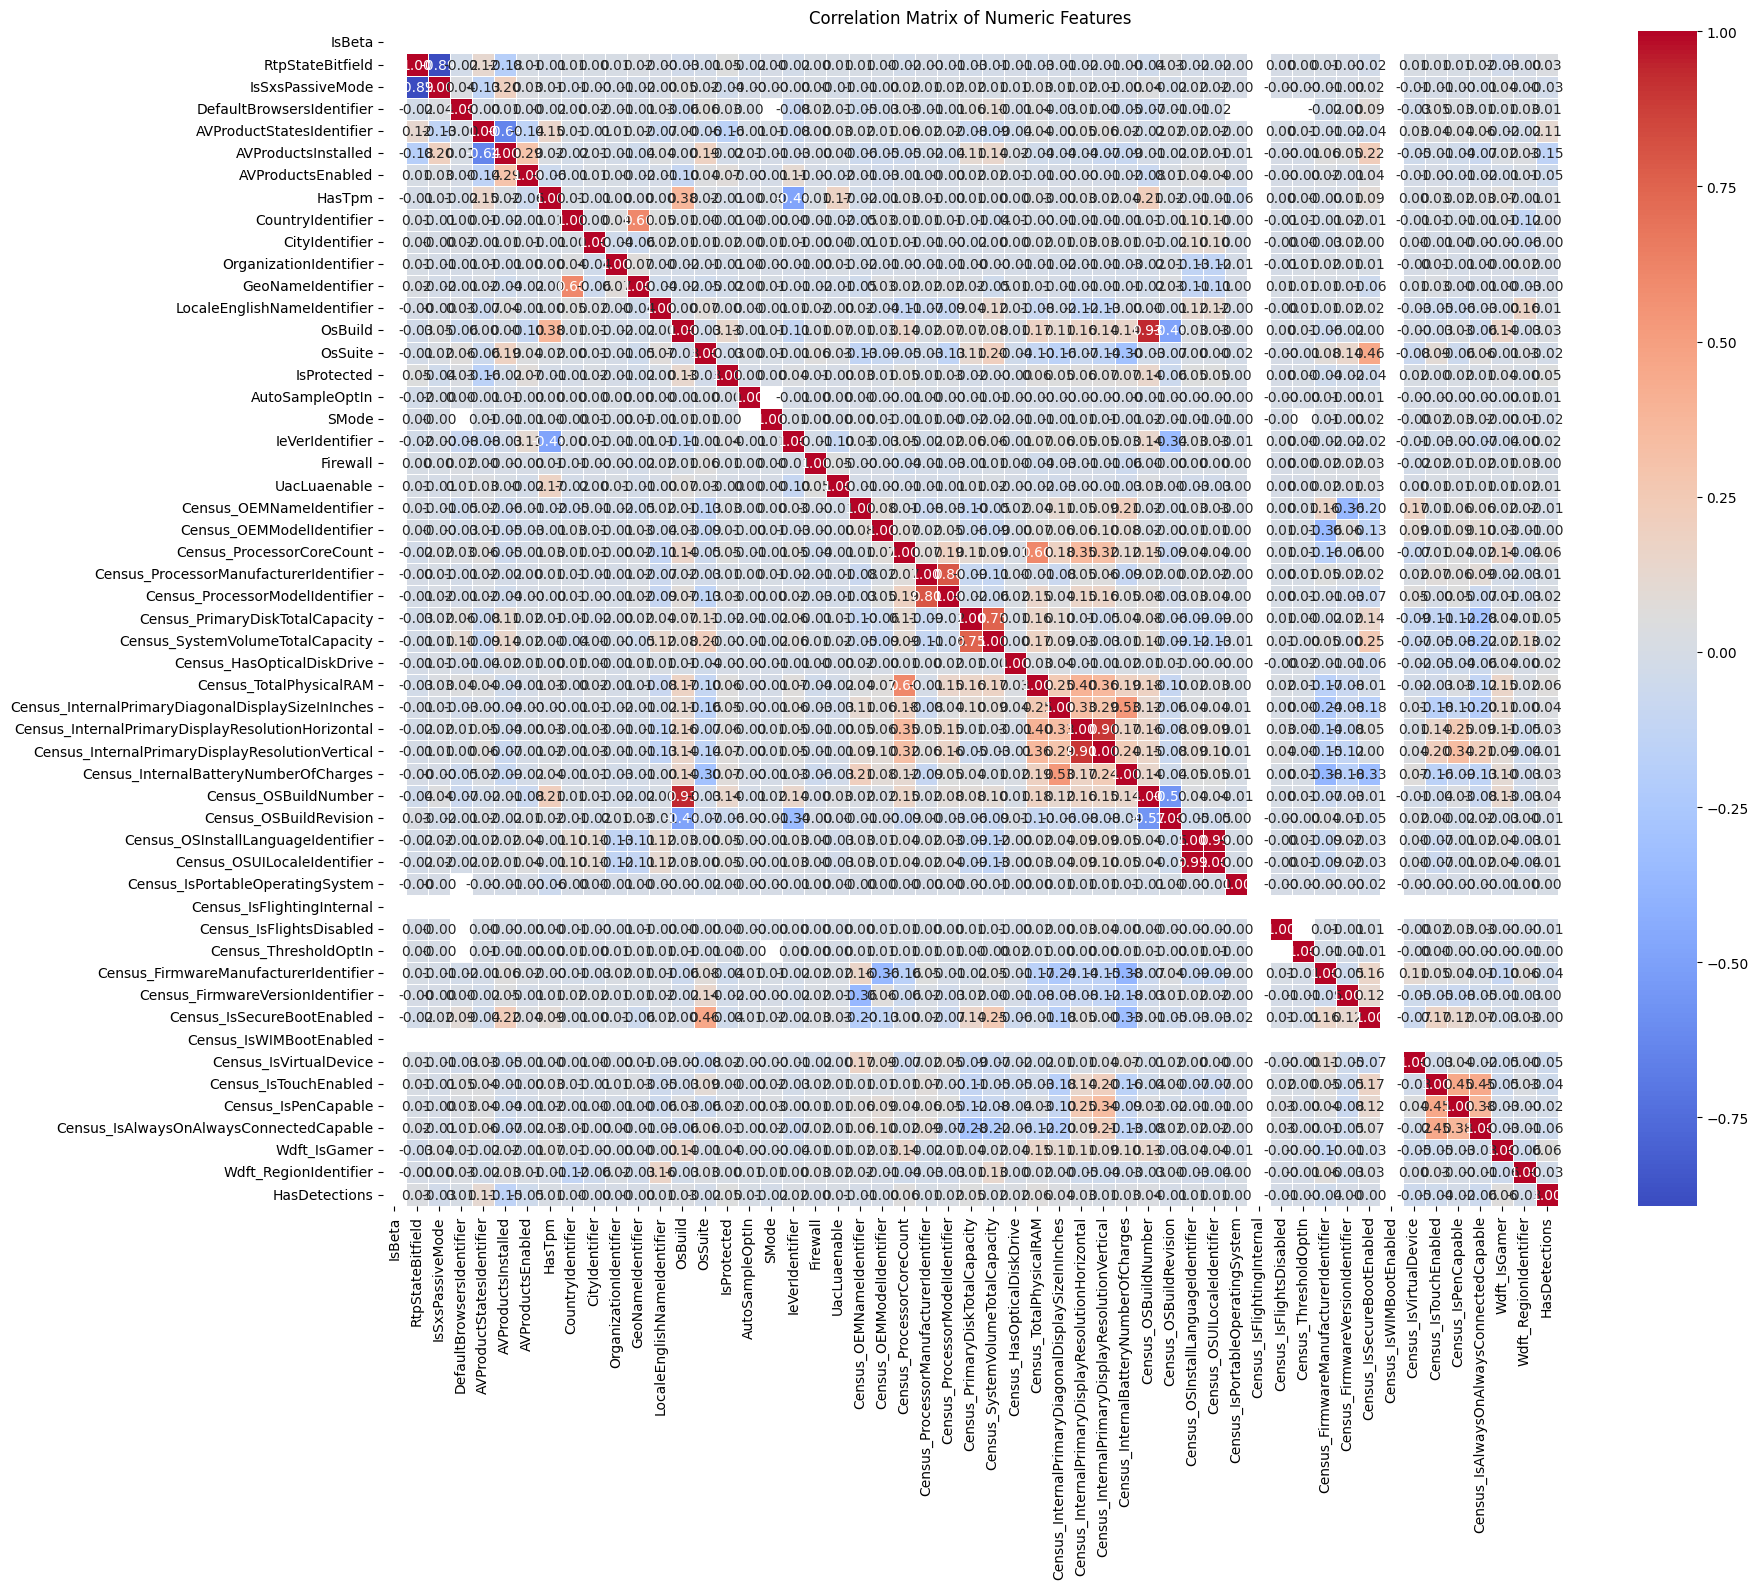

In [11]:
# Correlation Matrix
plt.figure(figsize=(20, 16))
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = data[numeric_cols].corr()

# Heatmap of correlations
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5, fmt=".2f", square=True)
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

In [12]:
# Detect_outliers
   
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns
outliers = {}
    
for col in numeric_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers_in_col = data[(data[col] < lower_bound) | (data[col] > upper_bound)].shape[0]
    outliers[col] = {
        'total_outliers': outliers_in_col,
        'percentage': (outliers_in_col / len(data)) * 100
    }
    
# Print columns with significant outliers
significant_outliers = {k:v for k,v in outliers.items() if v['percentage'] > 5}
print("\nColumns with Significant Outliers:")
for col, stats in significant_outliers.items():
    print(f"{col}: {stats['total_outliers']} outliers ({stats['percentage']:.2f}%)")


Columns with Significant Outliers:
AVProductStatesIdentifier: 10682 outliers (21.36%)
OsBuild: 5335 outliers (10.67%)
IsProtected: 2724 outliers (5.45%)
IeVerIdentifier: 3351 outliers (6.70%)
Census_OEMNameIdentifier: 5262 outliers (10.52%)
Census_ProcessorCoreCount: 5472 outliers (10.94%)
Census_ProcessorManufacturerIdentifier: 5901 outliers (11.80%)
Census_ProcessorModelIdentifier: 5250 outliers (10.50%)
Census_HasOpticalDiskDrive: 3821 outliers (7.64%)
Census_TotalPhysicalRAM: 3459 outliers (6.92%)
Census_InternalPrimaryDiagonalDisplaySizeInInches: 5349 outliers (10.70%)
Census_OSBuildNumber: 4733 outliers (9.47%)
Census_OSBuildRevision: 7054 outliers (14.11%)
Census_IsTouchEnabled: 6364 outliers (12.73%)
Census_IsAlwaysOnAlwaysConnectedCapable: 2788 outliers (5.58%)


# *Step 3. Data Preprocessing*

### 1. Extreme Missing Value Handling

* Drop columns with >90% missing data
* Prevents irrelevant feature inclusion

In [13]:
# 1. Drop columns with extreme missing values
columns_to_drop = data.columns[data.isnull().mean() > 0.9]
print("\nColumns Dropped due to Extreme Missing Values:")
print(columns_to_drop)
data = data.drop(columns=columns_to_drop)


Columns Dropped due to Extreme Missing Values:
Index(['DefaultBrowsersIdentifier', 'PuaMode', 'Census_ProcessorClass'], dtype='object')


### 2. Correlation-based Feature Reduction

* Remove highly correlated features (>0.9 correlation)
* Reduces multicollinearity

In [14]:
# 2. Handle Highly Correlated Features
# Create correlation matrix
corr_matrix = correlation_matrix.abs()

In [15]:
# Select upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

In [16]:
# Find features to drop and remove highly correlated features
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]
print("\nHighly Correlated Features to Remove:")
print(to_drop)  
data = data.drop(columns=to_drop)


Highly Correlated Features to Remove:
['Census_OSBuildNumber', 'Census_OSUILocaleIdentifier']


### 3. Robust Outlier Management

* Winsorization technique
* Clips extreme values using IQR method
* Preserves data distribution

In [17]:
# 3. Robust Outlier Handling (Winsorization)
numeric_columns = data.select_dtypes(include=['int64', 'float64']).columns
for col in numeric_columns:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    data[col] = np.clip(data[col], lower_bound, upper_bound)

In [18]:
# 4. Separate features and target
X = data.drop('HasDetections', axis=1)
y = data['HasDetections']

### 5. Comprehensive Feature Preprocessing

* Separate numeric and categorical transformations
* Handles missing values intelligently
* One-hot encoding for categorical features

In [19]:
# 5. Identify column types
numeric_columns = X.select_dtypes(include=['int64', 'float64']).columns
categorical_columns = X.select_dtypes(include=['object', 'category']).columns

In [20]:
# 6. Create Advanced preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [21]:
# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_columns),
        ('cat', categorical_transformer, categorical_columns)
    ])

### 7. Automated Feature Selection

* Uses RandomForest for feature importance
* Selects most relevant features

In [22]:
# 7. Full preprocessing pipeline with feature selection
feature_selector = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('selector', SelectFromModel(
        RandomForestClassifier(n_estimators=100, random_state=42), 
        prefit=False, 
        max_features=None
    ))
])

In [23]:
# Fit the selector
feature_selector.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['IsBeta', 'RtpStateBitfield', 'IsSxsPassiveMode',
       'AVProductStatesIdentifier', 'AVProductsInstalled', 'AVProductsEnabled',
       'HasTpm', 'CountryIdentifier', 'CityIdentifier',
       'OrganizationIdent...
       'Census_PowerPlatformRoleName', 'Census_InternalBatteryType',
       'Census_OSVersion', 'Census_OSArchitecture', 'Census_OSBranch',
       'Census_OSEdition', 'Census_OSSkuName', 'Census_OSInstallTypeName',
       'Census_OSWUAutoUpdateOptionsName', 'Census_GenuineStateName',
       'Census_ActivationChannel', 'Census_FlightRing'],
      dtype='object'))])),
                ('selector',
                 SelectFromModel(estimator=RandomForestClassifier(random_state=42)))])

In [24]:
# Get preprocessed feature names
preprocessed_features = (
    list(preprocessor.named_transformers_['num'].get_feature_names_out(numeric_columns)) +
    list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_columns))
)

In [25]:
# Get selected feature mask
feature_selector_steps = feature_selector.named_steps['selector']
feature_mask = feature_selector_steps.get_support()

# Get selected feature names
selected_preprocessed_features = [
    feature for feature, is_selected in zip(preprocessed_features, feature_mask)
    if is_selected
]

#print("\nSelected Features:")
#print(selected_preprocessed_features)

# *Step 4: Hyperparameter Tuning for RF*

In [26]:
# Combine preprocessor with classifier
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier())
])

# Hyperparameter grid
param_dist = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2]
}

# hyperparameter tuning
X_sample, _, y_sample, _ = train_test_split(
    X, y, 
    train_size=0.1,  # Reduce to 10% of original data
    stratify=y,      # Maintain class distribution
    random_state=42  # Ensure reproducibility
)

# Reduced random search parameters
random_search = RandomizedSearchCV(
    pipeline, 
    param_distributions=param_dist, 
    n_iter=10,       # Reduce number of iterations
    cv=5,            # Reduce cross-validation folds
    scoring='accuracy', 
    random_state=42,
    n_jobs=4         # Parallel processing
)

# Fit on the sampled data
random_search.fit(X_sample, y_sample)

print("\nBest Hyperparameters:")
print(random_search.best_params_)
print("\nBest Cross-Validated Score:")
print(random_search.best_score_)


Best Hyperparameters:
{'classifier__n_estimators': 200, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 2, 'classifier__max_depth': 20}

Best Cross-Validated Score:
0.6268


# *Step 5: Hyperparameter Tuning for SVM*

In [27]:
# Combine preprocessor with SVM classifier
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(probability=True))
])

# Optimized hyperparameter grid for SVM 
param_dist = {
    'classifier__C': [0.1, 1, 10],
    'classifier__kernel': ['rbf', 'linear'],
    'classifier__gamma': [0.01, 0.1, 1],
    'classifier__class_weight': [None, 'balanced']
}

# Random search with optimizations
random_search = RandomizedSearchCV(
    pipeline, 
    param_distributions=param_dist, 
    n_iter=5, # Reduced iterations
    cv=2, # Reduced cross-validation
    scoring='accuracy', 
    random_state=42,
    n_jobs=4        # Use 4 cores
)

# Fit on a subset as the full dataset is too large
X_sample, _, y_sample, _ = train_test_split(
    X, y, 
    train_size=0.1,  # 10% of data
    stratify=y,
    random_state=42
)

random_search.fit(X_sample, y_sample)

print("\nSVM Best Hyperparameters:")
print(random_search.best_params_)
print("\nSVM Best Cross-Validated Score:")
print(random_search.best_score_)


SVM Best Hyperparameters:
{'classifier__kernel': 'linear', 'classifier__gamma': 0.01, 'classifier__class_weight': None, 'classifier__C': 1}

SVM Best Cross-Validated Score:
0.5996


# *Step 6: Cross-Validation for Random Forest*

#### Parameters:
    - model: Trained model
    - X: Features
    - y: Target variable
    - cv: Number of cross-validation folds

In [28]:
# Use the best model from hyperparameter tuning
best_model = random_search.best_estimator_

# Use a smaller, stratified sample (10-20% of data)
X_sample, _, y_sample, _ = train_test_split(
    X, y, 
    train_size=0.1,  # Reduce to 10% of original data
    stratify=y,      # Maintain class distribution
    random_state=42  # Ensure reproducibility
)

# Perform cross-validation on the best model
cv_scores = cross_val_score(best_model, X_sample, y_sample, cv=2, scoring='accuracy', n_jobs=4)

print("\nCross-Validation Scores:")
print(cv_scores)
print(f"Mean CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")


Cross-Validation Scores:
[0.6008 0.5984]
Mean CV Score: 0.5996 (+/- 0.0024)


# *Step 7: Train Final Random Forest Model*

### Key Splitting Considerations:

* Stratified splitting preserves the proportion of target classes
* Separate training and testing datasets prevent overfitting
* Reproducible random state ensures consistent results

In [29]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y 
)
# test_size: Proportion of test set
# random_state: Seed for reproducibility

### Pipeline Benefits:

* Combines preprocessing and classification
* Ensures consistent data transformation
* Simplifies model training and prediction

In [30]:
# Create full pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

In [31]:
# Train Random Forest classifier
# Applies preprocessing to training data
pipeline.fit(X_train, y_train)
rf_model =pipeline

In [32]:
# Predictions
# applies the preprocessor to X_test
y_pred = pipeline.predict(X_test)

### Performance Evaluation Metrics 
#### Accuracy - Percentage of correct predictions
* can be misleading for imbalanced datasets
#### Classification Report - Provides detailed performance metrics:
* Precision: Correctly predicted positive observations
* Recall: Percentage of actual positives correctly identified
* F1-Score: Balanced measure of precision and recall
* Support: Number of occurrences of each class
#### Confusion Matrix Visualization- A heatmap showing:
* True Positives (TP)
* True Negatives (TN)
* False Positives (FP)
* False Negatives (FN)


Model Performance Comparison:
Training Set Accuracy: 1.0000
Test Set Accuracy: 0.6125


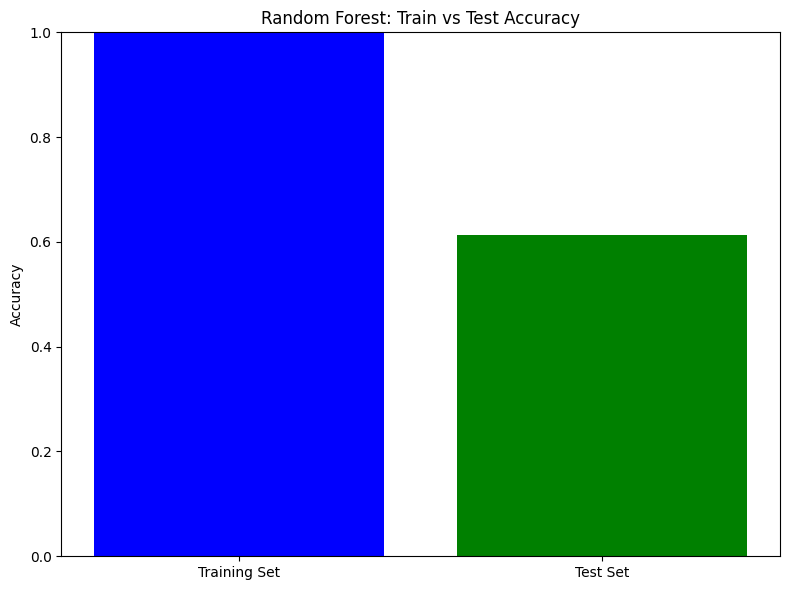

In [33]:
# Calculate and display train and test accuracies
y_train_pred = pipeline.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_pred)

print("\nModel Performance Comparison:")
print(f"Training Set Accuracy: {train_accuracy:.4f}")
print(f"Test Set Accuracy: {test_accuracy:.4f}")

# Simple visualization
plt.figure(figsize=(8, 6))
plt.bar(['Training Set', 'Test Set'], [train_accuracy, test_accuracy], color=['blue', 'green'])
plt.title('Random Forest: Train vs Test Accuracy')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [34]:
# Evaluation Metrics
print("\nFinal Model Evaluation Metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred)) # Accuracy: Percentage of correct predictions
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Final Model Evaluation Metrics:
Accuracy: 0.6125

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.62      0.61      4996
           1       0.61      0.61      0.61      5004

    accuracy                           0.61     10000
   macro avg       0.61      0.61      0.61     10000
weighted avg       0.61      0.61      0.61     10000



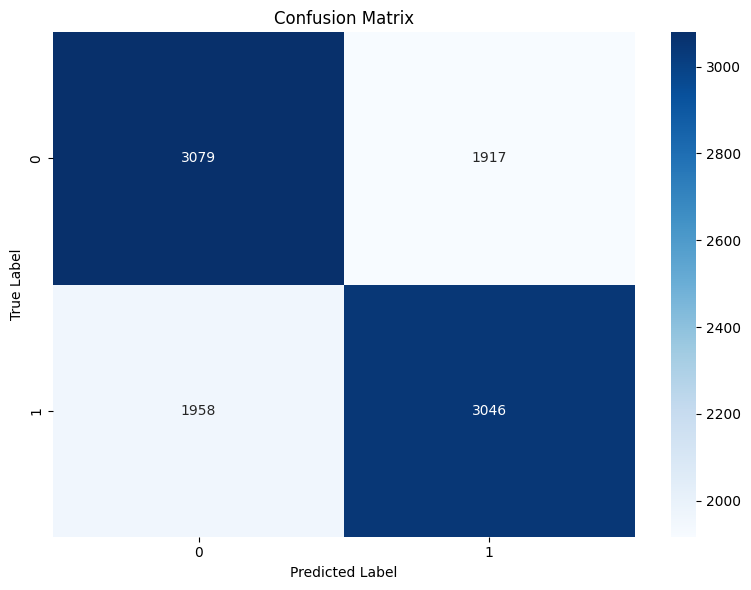

In [35]:
# Confusion Matrix
rf_cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [36]:
# Confusion Matrix Interpretation for RF
TN, FP = rf_cm[0, 0], rf_cm[0, 1]
FN, TP = rf_cm[1, 0], rf_cm[1, 1]

print(f"\nRandom Forest Confusion Matrix Interpretation:")
print(f"True Negatives (Correctly predicted No Malware): {TN}")
print(f"False Positives (Incorrectly predicted Malware): {FP}")
print(f"False Negatives (Incorrectly predicted No Malware): {FN}")
print(f"True Positives (Correctly predicted Malware): {TP}")


Random Forest Confusion Matrix Interpretation:
True Negatives (Correctly predicted No Malware): 3079
False Positives (Incorrectly predicted Malware): 1917
False Negatives (Incorrectly predicted No Malware): 1958
True Positives (Correctly predicted Malware): 3046


# *Step 8: Train Final SVM Model*

In [37]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [38]:
# Create full pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), # Preprocessing: Applies the previously defined transformations
    ('classifier', SVC(probability=True, random_state=42))
])

In [39]:
# Train the model
# SVM model using the preprocessed training data
pipeline.fit(X_train, y_train)
svm_model = pipeline

In [40]:
# Predictions
# Generates predictions on the test set using the trained model
y_pred = pipeline.predict(X_test)


SVM Model Performance Comparison:
Training Set Accuracy: 0.7195
Test Set Accuracy: 0.6285


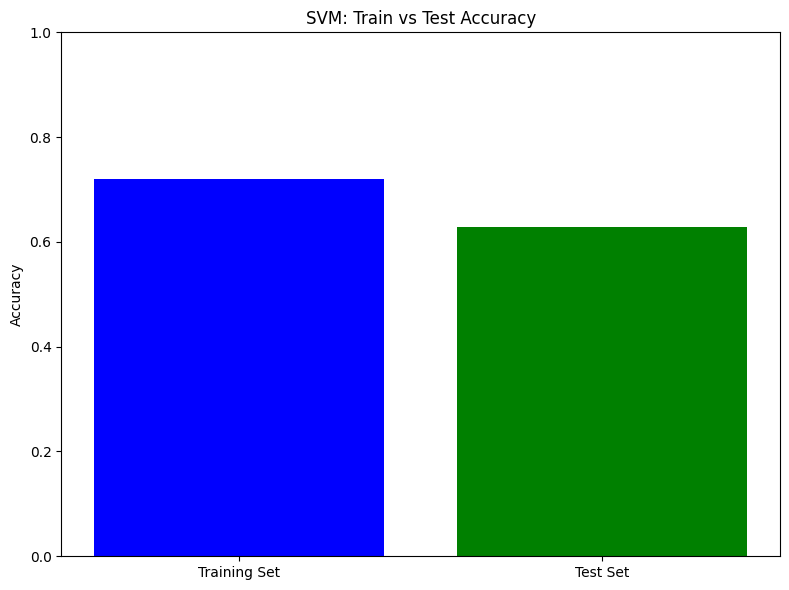

In [41]:
# Calculate and display train and test accuracies
y_train_pred = pipeline.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_pred)

print("\nSVM Model Performance Comparison:")
print(f"Training Set Accuracy: {train_accuracy:.4f}")
print(f"Test Set Accuracy: {test_accuracy:.4f}")

# Simple visualization
plt.figure(figsize=(8, 6))
plt.bar(['Training Set', 'Test Set'], [train_accuracy, test_accuracy], color=['blue', 'green'])
plt.title('SVM: Train vs Test Accuracy')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [42]:
# Evaluation Metrics
print("\nSVM Final Model Evaluation Metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nSVM Classification Report:")
print(classification_report(y_test, y_pred))


SVM Final Model Evaluation Metrics:
Accuracy: 0.6285

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.66      0.64      4996
           1       0.64      0.60      0.62      5004

    accuracy                           0.63     10000
   macro avg       0.63      0.63      0.63     10000
weighted avg       0.63      0.63      0.63     10000



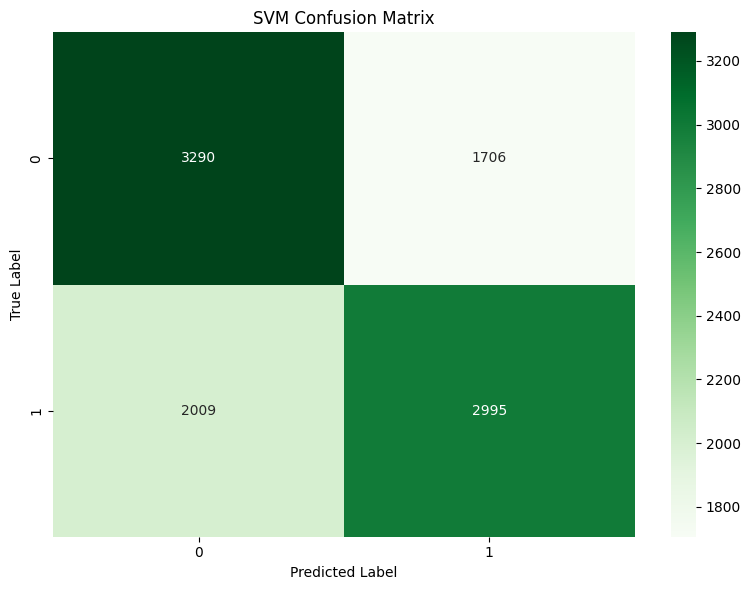

In [43]:
# Confusion Matrix
svm_cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(svm_cm, annot=True, fmt='d', cmap='Greens')
plt.title('SVM Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [44]:
# Confusion Matrix Interpretation for SVM
TN, FP = svm_cm[0, 0], svm_cm[0, 1]
FN, TP = svm_cm[1, 0], svm_cm[1, 1]

print(f"\nSVM Confusion Matrix Interpretation:")
print(f"True Negatives (Correctly predicted No Malware): {TN}")
print(f"False Positives (Incorrectly predicted Malware): {FP}")
print(f"False Negatives (Incorrectly predicted No Malware): {FN}")
print(f"True Positives (Correctly predicted Malware): {TP}")


SVM Confusion Matrix Interpretation:
True Negatives (Correctly predicted No Malware): 3290
False Positives (Incorrectly predicted Malware): 1706
False Negatives (Incorrectly predicted No Malware): 2009
True Positives (Correctly predicted Malware): 2995


# *Step 9: Compare Model Performances*

### Context Matters
#### In malware detection:
* Recall might be more critical (catching potential threats)
* Precision helps reduce false alarms
* F1 score provides a balanced perspective

In [45]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [46]:
# Predictions
rf_pred = rf_model.predict(X_test)
svm_pred = svm_model.predict(X_test)

In [47]:
# Comparison Metrics
print("\n--- Model Performance Comparison ---")

print("\nRandom Forest Performance:")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))

print("\nSVM Performance:")
print("Accuracy:", accuracy_score(y_test, svm_pred))
print("Precision:", precision_score(y_test, svm_pred))
print("Recall:", recall_score(y_test, svm_pred))
print("F1 Score:", f1_score(y_test, svm_pred))


--- Model Performance Comparison ---

Random Forest Performance:
Accuracy: 0.6125
Precision: 0.613741688494862
Recall: 0.6087130295763389
F1 Score: 0.6112170161533059

SVM Performance:
Accuracy: 0.6285
Precision: 0.6370984896830462
Recall: 0.5985211830535572
F1 Score: 0.6172076249356002


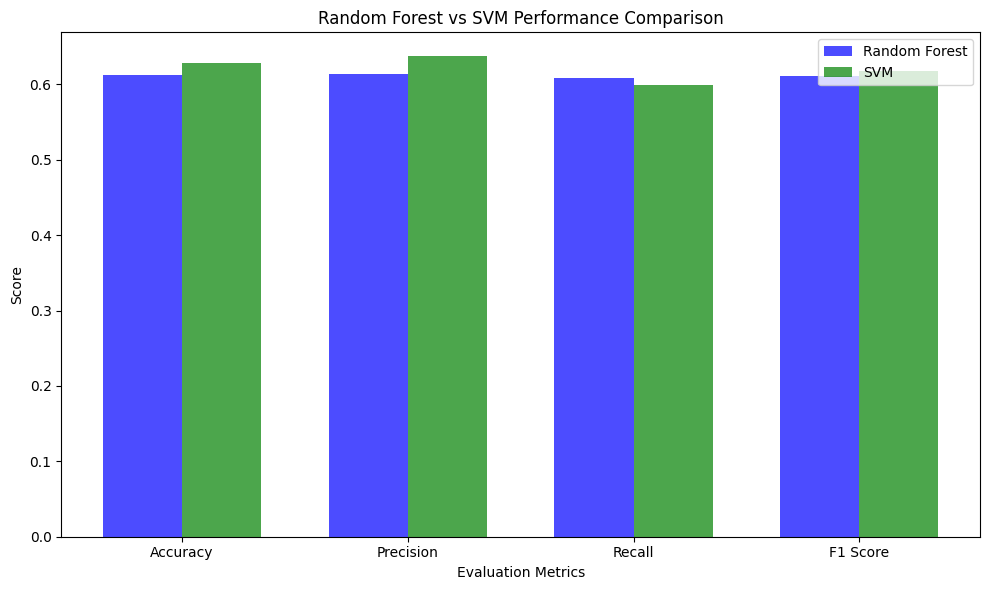

In [48]:
# Visualization of performance comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
rf_scores = [
    accuracy_score(y_test, rf_pred),
    precision_score(y_test, rf_pred),
    recall_score(y_test, rf_pred),
    f1_score(y_test, rf_pred)
]
svm_scores = [
    accuracy_score(y_test, svm_pred),
    precision_score(y_test, svm_pred),
    recall_score(y_test, svm_pred),
    f1_score(y_test, svm_pred)
]

plt.figure(figsize=(10, 6))
x = np.arange(len(metrics))
width = 0.35

plt.bar(x - width/2, rf_scores, width, label='Random Forest', color='blue', alpha=0.7)
plt.bar(x + width/2, svm_scores, width, label='SVM', color='green', alpha=0.7)

plt.xlabel('Evaluation Metrics')
plt.ylabel('Score')
plt.title('Random Forest vs SVM Performance Comparison')
plt.xticks(x, metrics)
plt.legend()
plt.tight_layout()
plt.show()

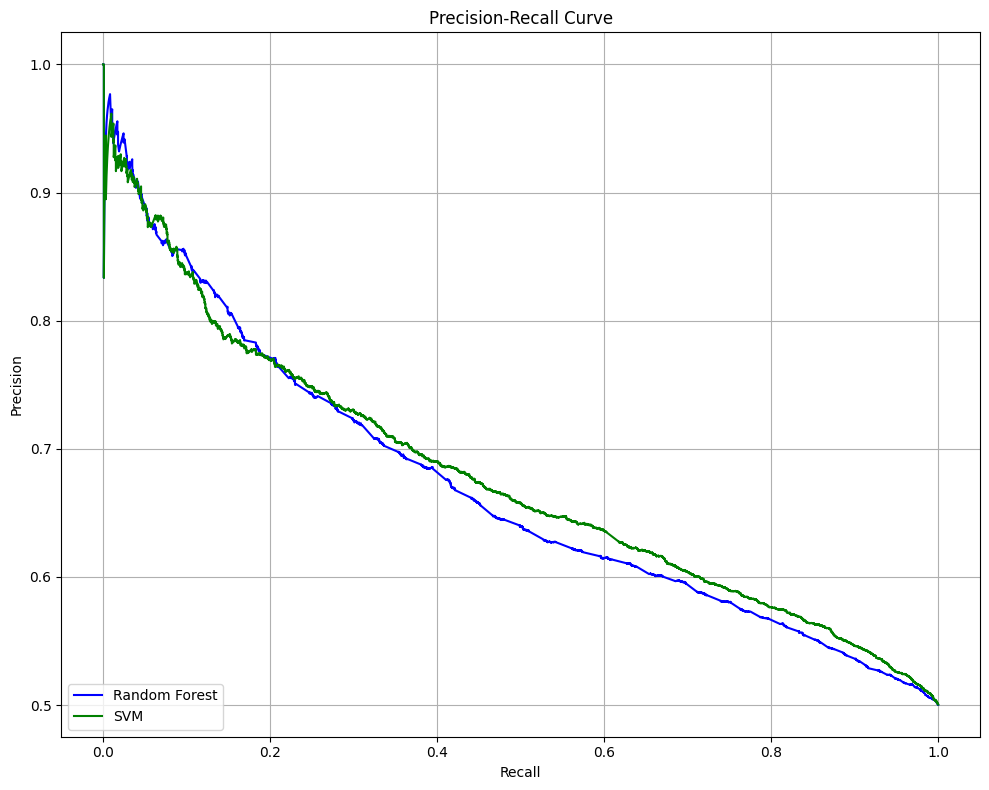

In [49]:
# Precision-Recall Curve
rf_precision, rf_recall, rf_thresholds = precision_recall_curve(y_test, rf_model.predict_proba(X_test)[:,1])
svm_precision, svm_recall, svm_thresholds = precision_recall_curve(y_test, svm_model.predict_proba(X_test)[:,1])

plt.figure(figsize=(10, 8))
plt.plot(rf_recall, rf_precision, color='blue', label='Random Forest')
plt.plot(svm_recall, svm_precision, color='green', label='SVM')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(True)
plt.tight_layout()
plt.show()

In [50]:
# ROC Curve
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_model.predict_proba(X_test)[:,1])
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_model.predict_proba(X_test)[:,1])

rf_roc_auc = auc(rf_fpr, rf_tpr)
svm_roc_auc = auc(svm_fpr, svm_tpr)

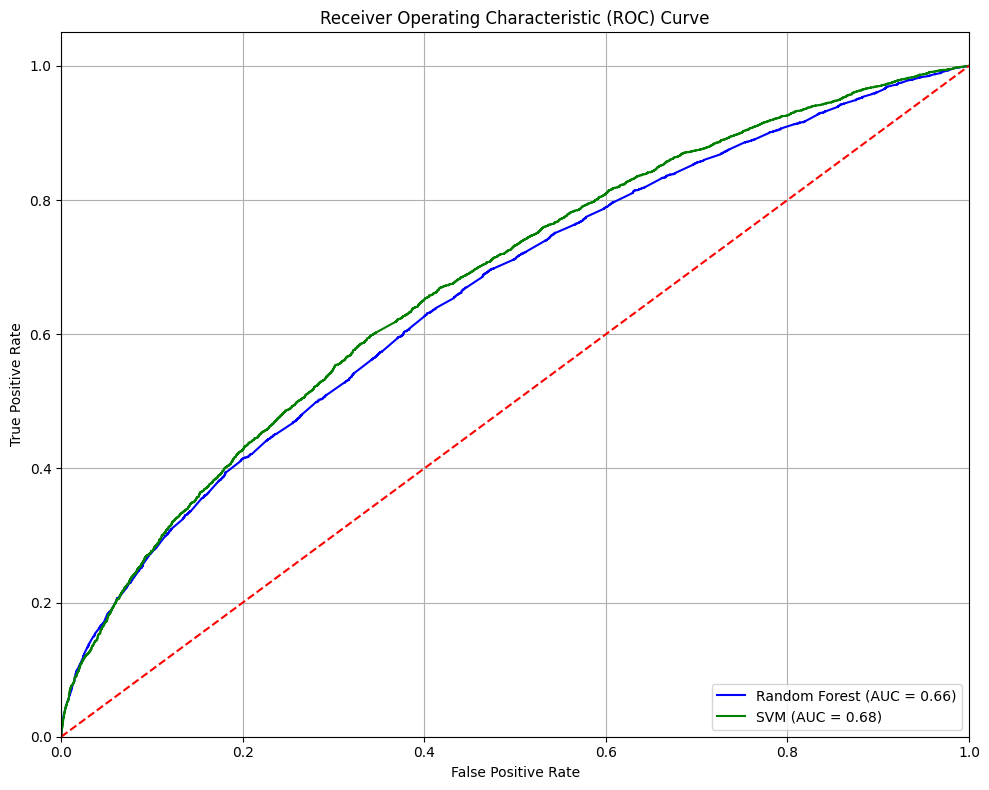

In [51]:
# ROC Curve Plotting
plt.figure(figsize=(10, 8))
plt.plot(rf_fpr, rf_tpr, color='blue', 
         label=f'Random Forest (AUC = {rf_roc_auc:.2f})')
plt.plot(svm_fpr, svm_tpr, color='green', 
         label=f'SVM (AUC = {svm_roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# Conclusion

### Numerical Performance Metrics:

* Accuracy: SVM (0.6285) slightly better than Random Forest (0.6125)
* Precision: SVM (0.637) slightly better than Random Forest (0.614)
* Recall: Random Forest (0.609) slightly better than SVM (0.599)
* F1 Score: SVM (0.617) marginally better than Random Forest (0.611)


### Visualization Comparisons:

* Bar Chart: Shows very close performance across metrics
* Precision-Recall Curve: Curves are quite similar, with slight variations
* ROC Curve: Both models have comparable performance, with curves close to each other


### Recommendation:

* The SVM model appears marginally better across most metrics
* However, the differences are minimal (less than 2% across metrics)

## References

1. Scikit-learn Documentation. Machine Learning in Python.
2. Microsoft Malware Prediction Dataset, Kaggle.
ggle.